## Preamble

In [ ]:
# dependencies.
import sys
import ast
import logging
from pathlib import Path

import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error, mean_poisson_deviance
)


# initialize logger.
log = logging.getLogger(__name__)
log.addHandler(logging.StreamHandler(stream=sys.stdout))
log.setLevel(logging.INFO)

log.info("Log initialized.")

# set seed.
RANDOM_SEED = 4890
np.random.seed(RANDOM_SEED)

# directories.
DATA_DIR = Path("../_data").resolve()
OUTPUT_DIR = Path("../output").resolve()

# load training data.
df_train = pd.read_csv(DATA_DIR / "train_encoded.csv")

# load feature selections from variable clustering.
feat_select = pd.read_csv(OUTPUT_DIR / "varreduction_stats.csv")

# keep selected features.
threshold_select = 1
features = list(ast.literal_eval(feat_select.loc[
    feat_select["threshold"] == threshold_select, 
    "selected_vars"
].iloc[0]))
df_train = df_train[features + ["clm", "numclaims", "claimcst0", "sample", "id"]]

# split by sample.
train = df_train[df_train["sample"] == "1|bld"].copy()
validate = df_train[df_train["sample"] == "2|val"].copy()

Log initialized.


## XGBoost

### Utils

In [2]:
def log_reg_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                    label: str = "", freq_model: bool = False) -> None:
    """Logs regression metrics."""
    
    log.info(f"\n{'='*80}")
    log.info(f"Regression Results: {label}")
    log.info(f"{'-'*80}")
    
    log.info(f"N: {len(y_true)}")
    log.info(f"RMSE: {root_mean_squared_error(y_true=y_true, y_pred=y_pred)}")
    log.info(f"MAE: {mean_absolute_error(y_true=y_true, y_pred=y_pred)}")
    
    non_zero = y_true != 0
    if non_zero.sum() > 0:
        mape = np.mean(np.abs(
            (y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero]
        )) * 100
        log.info(f"MAPE: {mape}%")
    else:
        log.info("MAPE: N/A")
        
    if freq_model:
        y_pred_pos = np.maximum(y_pred, 1e-10)
        poisson_dev = mean_poisson_deviance(y_true=y_true, y_pred=y_pred_pos)
        print(f"Poisson Deviance: {poisson_dev}")
    
    print(f"Mean Actual: {y_true.mean()}")
    print(f"Mean Predicted: {y_pred.mean()}")
    
    log.info(f"{'='*80}\n")
    
    return None

### Frequency Model

In [3]:
# splits/arrays.
x_train_freq = train[features].copy()
y_train_freq = train["numclaims"].copy()
x_validate_freq = validate[features].copy()
y_validate_freq = validate["numclaims"].copy()

# weight by exposure.
train_wgt = train["exposure"].values
validate_wgt = validate["exposure"].values

# create model.
xgb_reg = xgb.XGBRegressor(
    objective="count:poisson",
    eval_metric="poisson-nloglik",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="auto"
)

param_freq = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 6, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [50, 100, 150],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1.0, 2.0, 5.0],
    "gamma": [0, 0.1, 0.2]
}

freq_hyper = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_freq,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
freq_hyper.fit(X=x_train_freq, y=y_train_freq, sample_weight=train_wgt)

log.info(f"\n\nBest hyper-parameters: {freq_hyper.best_params_}")

# validation metrics & featrue import.
freq_model: xgb.XGBRegressor = freq_hyper.best_estimator_   # type: ignore

y_freq_pred_train = freq_model.predict(x_train_freq)
log_reg_metrics(
    y_true=np.array(y_train_freq.values), 
    y_pred=y_freq_pred_train, 
    label="Frequency Model - Training Set",
    freq_model=True
)

y_freq_pred_validate = freq_model.predict(x_validate_freq)
log_reg_metrics(
    y_true=np.array(y_validate_freq.values), 
    y_pred=y_freq_pred_validate,
    label="Frequency Model - Validation Set",
    freq_model=True
)

freq_importance = pd.DataFrame({
    "feature": features,
    "importance": freq_model.feature_importances_
})
freq_importance = freq_importance.sort_values("importance", ascending=False)
log.info(
    "\nTop 10 Feature Importance (Frequency model):\n"
    f"{freq_importance.head(10)}"
)

# export.
freq_model.save_model(OUTPUT_DIR / "xgboost_freq_model.json")

Fitting 5 folds for each of 25 candidates, totalling 125 fits


Best hyper-parameters: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 50, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.6}

Regression Results: Frequency Model - Training Set
--------------------------------------------------------------------------------
N: 11204
RMSE: 0.2672213613986969
MAE: 0.14616014063358307
MAPE: 89.55061025140417%
Poisson Deviance: 0.36667272448539734
Mean Actual: 0.07184933952159943
Mean Predicted: 0.08905642479658127


Regression Results: Frequency Model - Validation Set
--------------------------------------------------------------------------------
N: 3796
RMSE: 0.2696731984615326
MAE: 0.1467609852552414
MAPE: 89.89306371001636%
Poisson Deviance: 0.37258756160736084
Mean Actual: 0.07112750263435196
Mean Predicted: 0.08962597697973251


Top 10 Feature Importance (Frequency model):
                        feature  impor

---

### Severity Model

In [4]:
# onmly want positive claims.
train_sev = train[train["clm"] == 1].copy()
validate_sev = validate[validate["clm"] == 1].copy()

# splits/arrays.
x_train_sev = train_sev[features].copy()
y_train_sev = train_sev["claimcst0"].copy()
x_validate_sev = validate_sev[features].copy()
y_validate_sev = validate_sev["claimcst0"].copy()

# weight by exposure.
train_wgt_sev = train_sev["exposure"].values
validate_wgt_sev = validate_sev["exposure"].values

# create model.
xgb_sev = xgb.XGBRegressor(
    objective="reg:gamma",
    eval_metric="gamma-nloglik",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="auto"
)

param_sev = {
    "n_estimators": [100, 200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha": [0, 0.05, 0.1, 0.5],
    "reg_lambda": [1.0, 2.0, 5.0],
    "gamma": [0, 0.1, 0.2, 0.5]
}

sev_hyper = RandomizedSearchCV(
    estimator=xgb_sev,
    param_distributions=param_sev,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

sev_hyper.fit(X=x_train_sev, y=y_train_sev, sample_weight=train_wgt_sev)

log.info(f"\n\nBest hyper-parameters: {sev_hyper.best_params_}")

# validation metrics & featrue import.
sev_model: xgb.XGBRegressor = sev_hyper.best_estimator_ # type: ignore

y_sev_pred_train = sev_model.predict(x_train_sev)
log_reg_metrics(
    y_true=np.array(y_train_sev.values), 
    y_pred=y_sev_pred_train, 
    label="Severity Model - Training Set"
)

y_sev_pred_validate = sev_model.predict(x_validate_sev)
log_reg_metrics(
    y_true=np.array(y_validate_sev.values), 
    y_pred=y_sev_pred_validate, 
    label="Severity Model - Validation Set"
)

sev_importance = pd.DataFrame({
    "feature": features,
    "importance": sev_model.feature_importances_
})
sev_importance = sev_importance.sort_values("importance", ascending=False)

log.info(
    "\nTop 10 Feature Importance (Severity model):\n"
    f"{freq_importance.head(10)}"
)

# export.
sev_model.save_model(OUTPUT_DIR / "xgboost_sev_model.json")


Fitting 5 folds for each of 25 candidates, totalling 125 fits


Best hyper-parameters: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 0.05, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}

Regression Results: Severity Model - Training Set
--------------------------------------------------------------------------------
N: 767
RMSE: 4641.567828085192
MAE: 3408.3104540797344
MAPE: 67.79819995905947%
Mean Actual: 6892.247066228161
Mean Predicted: 6558.24755859375


Regression Results: Severity Model - Validation Set
--------------------------------------------------------------------------------
N: 255
RMSE: 5770.337157157181
MAE: 4328.570791625613
MAPE: 83.25807614284389%
Mean Actual: 7324.854654533332
Mean Predicted: 6679.580078125


Top 10 Feature Importance (Severity model):
                        feature  importance
22                     exposure    0.197066
26                       area_a    0.134724
15  

### Combined Model

In [5]:

# predict on full dataset.
freq_pred_train_full = freq_model.predict(x_train_freq)
freq_pred_validate_full = freq_model.predict(x_validate_freq)

sev_pred_train_full = sev_model.predict(x_train_freq)
sev_pred_validate_full = sev_model.predict(x_validate_freq)

# calc. expected loss = frequency × severity
expected_loss_train = freq_pred_train_full * sev_pred_train_full
expected_loss_validate = freq_pred_validate_full * sev_pred_validate_full

# actual total claim cost.
actual_loss_train = np.array(train["claimcst0"].values)
actual_loss_validate = np.array(validate["claimcst0"].values)

# metrics.
combined_metrics_train = log_reg_metrics(
    y_true=actual_loss_train, 
    y_pred=expected_loss_train, 
    label="Combined Model - Training Set"
)

combined_metrics_val = log_reg_metrics(
    y_true=actual_loss_validate, 
    y_pred=expected_loss_validate, 
    label="Combined Model - Validation Set"
)

# calc. premium (per unit exposure).
prem_actual_val = np.array(actual_loss_validate / validate["exposure"].values)
prem_pred_val = np.array(expected_loss_validate / validate["exposure"].values)

log.info(f"\n{'='*80}")
log.info("Premium Statistics:")
log.info(f"{'-'*80}")
log.info(f"Actual Mean: ${round(prem_actual_val.mean(), 2)}")
log.info(f"Predicted Mean: ${round(prem_pred_val.mean(), 2)}")
log.info(f"Acutal Median: ${np.median(prem_actual_val)}")
log.info(f"Predicted Median: ${np.median(prem_pred_val)}")
log.info(f"{'='*80}\n")

# export.
sev_model.save_model(OUTPUT_DIR / "xgboost_sev_model.json")


Regression Results: Combined Model - Training Set
--------------------------------------------------------------------------------
N: 11204
RMSE: 2217.709400876639
MAE: 917.6652051450983
MAPE: 84.68676841871331%
Mean Actual: 471.82733843243483
Mean Predicted: 545.3334350585938


Regression Results: Combined Model - Validation Set
--------------------------------------------------------------------------------
N: 3796
RMSE: 2351.24559422546
MAE: 947.6158247328523
MAPE: 84.23275710337475%
Mean Actual: 492.0542510289779
Mean Predicted: 550.9756469726562


Premium Statistics:
--------------------------------------------------------------------------------
Actual Mean: $848.35
Predicted Mean: $1955.99
Acutal Median: $0.0
Predicted Median: $1325.0368220164314



## Figures

/var/folders/6q/zww1c4xj04d9c7jlxyz1zc6c0000gn/T/ipykernel_37497/692255105.py:61: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


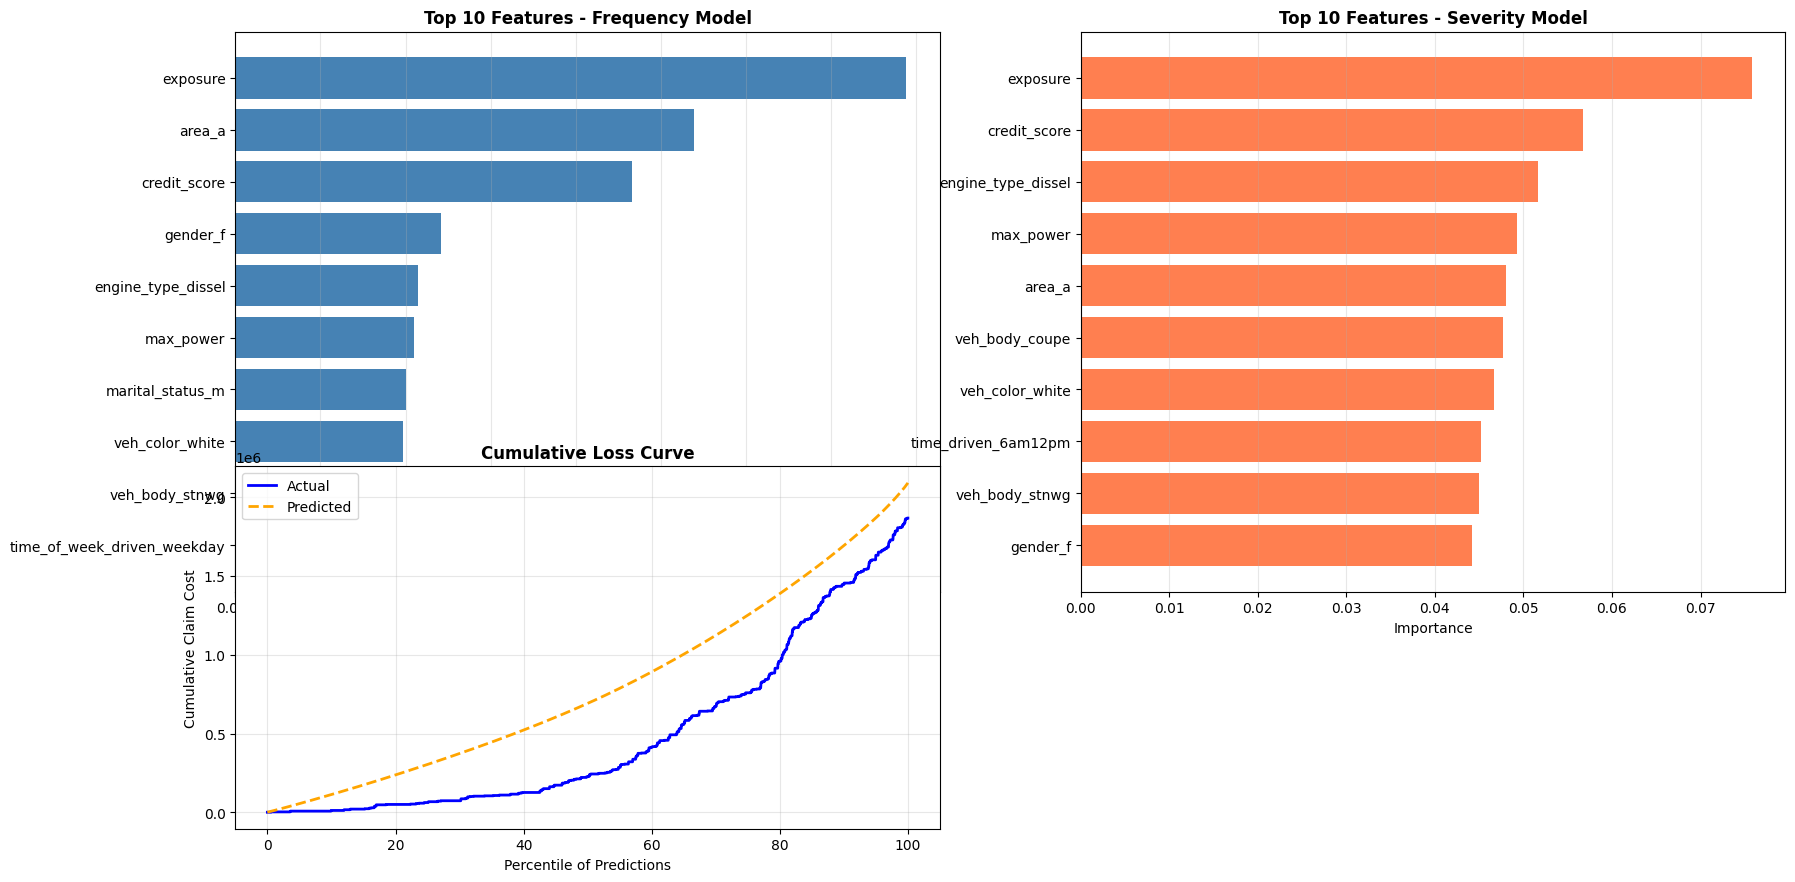

/var/folders/6q/zww1c4xj04d9c7jlxyz1zc6c0000gn/T/ipykernel_37497/692255105.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


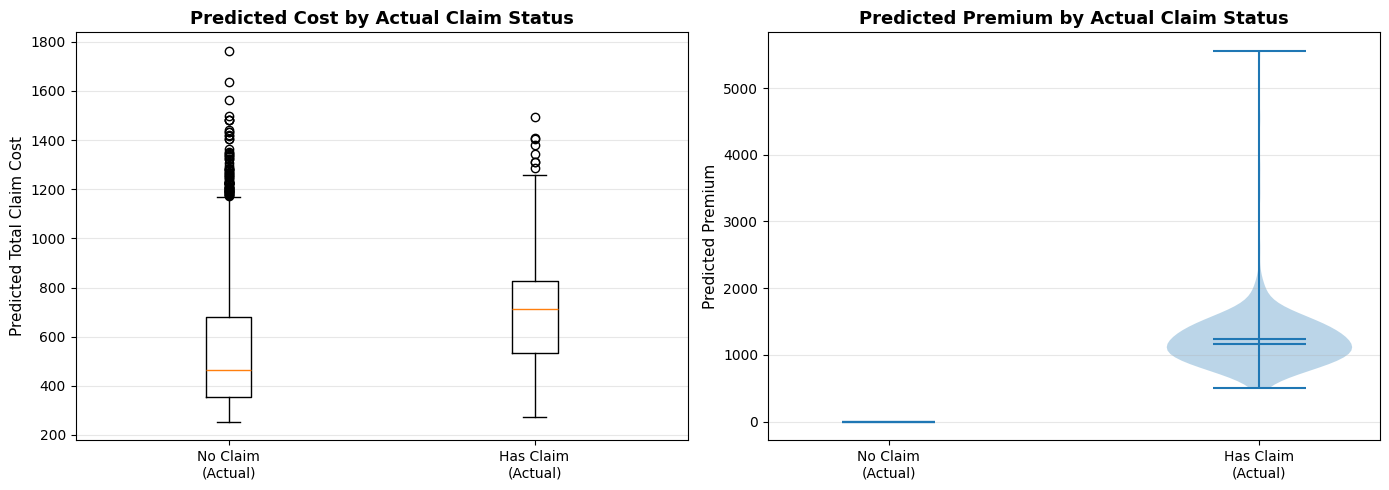

In [6]:
fig = plt.figure(figsize=(20, 16))

# feature importance.
ax1 = plt.subplot(2, 2, 1)
top_freq = freq_importance.head(10)
y = range(len(top_freq))
ax1.barh(y=y, width=np.array(top_freq["importance"].values), color="steelblue")
ax1.set_yticks(ticks=y)
ax1.set_yticklabels(labels=top_freq["feature"].values)
ax1.set_xlabel(xlabel="Importance", fontsize=10)
ax1.set_title(
    label="Top 10 Features - Frequency Model", 
    fontsize=12, 
    fontweight="bold"
)
ax1.invert_yaxis()
ax1.grid(visible=True, alpha=0.3, axis="x")

ax2 = plt.subplot(2, 2, 2)
top_sev = sev_importance.head(10)
y = range(len(top_sev))
ax2.barh(y=y, width=np.array(top_sev["importance"].values), color="coral")
ax2.set_yticks(ticks=y)
ax2.set_yticklabels(labels=top_sev["feature"].values)
ax2.set_xlabel(xlabel="Importance", fontsize=10)
ax2.set_title(
    label="Top 10 Features - Severity Model", 
    fontsize=12, 
    fontweight="bold"
)
ax2.invert_yaxis()
ax2.grid(visible=True, alpha=0.3, axis="x")

# cummulative loss.
ax3 = plt.subplot(3, 2, 3)
sorted_indices = np.argsort(expected_loss_validate)
cumulative_actual = np.cumsum(actual_loss_validate[sorted_indices])
cumulative_pred = np.cumsum(expected_loss_validate[sorted_indices])
percentiles = np.arange(len(sorted_indices)) / len(sorted_indices) * 100
ax3.plot(
    percentiles, 
    cumulative_actual, 
    label="Actual", 
    linewidth=2, 
    color="blue"
)
ax3.plot(
    percentiles, 
    cumulative_pred, 
    label="Predicted", 
    linewidth=2, 
    linestyle="--", 
    color="orange"
)
ax3.set_xlabel(xlabel="Percentile of Predictions", fontsize=10)
ax3.set_ylabel(ylabel="Cumulative Claim Cost", fontsize=10)
ax3.set_title(label="Cumulative Loss Curve", fontsize=12, fontweight="bold")
ax3.legend()
ax3.grid(visible=True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost.png", dpi=600, bbox_inches="tight")
plt.show()

# prediction by claim stat.
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

has_claim = validate["clm"] == 1
no_claim = validate["clm"] == 0

axes[0].boxplot(
    [expected_loss_validate[no_claim], expected_loss_validate[has_claim]], 
    labels=["No Claim\n(Actual)", "Has Claim\n(Actual)"]
)
axes[0].set_ylabel("Predicted Total Claim Cost", fontsize=11)
axes[0].set_title("Predicted Cost by Actual Claim Status", fontsize=13, fontweight="bold")
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].violinplot(
    [prem_actual_val[no_claim], prem_pred_val[has_claim]], 
    positions=[1, 2], 
    showmeans=True, 
    showmedians=True
)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["No Claim\n(Actual)", "Has Claim\n(Actual)"])
axes[1].set_ylabel(ylabel="Predicted Premium", fontsize=11)
axes[1].set_title(
    label="Predicted Premium by Actual Claim Status", 
    fontsize=13, 
    fontweight="bold"
)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_clmstat.png", dpi=600, bbox_inches="tight")
plt.show()